In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = '/content/drive/MyDrive/Final_Year_Project/Results/'
y_true = np.load(base + 'ag_y_true.npy')

models = {
    'Logistic Regression': np.load(base + 'lr_y_prob.npy'),
    'H2O AutoML': np.load(base + 'h2o_y_prob.npy'),
    'AutoGluon': np.load(base + 'ag_y_prob.npy')
}

thresholds = np.linspace(0.01, 0.99, 99)

def expected_cost(y_true, y_prob, thr, c_miss, c_fa):
    pred = (y_prob >= thr).astype(int)
    fn = ((pred == 0) & (y_true == 1)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    return c_miss * fn + c_fa * fp

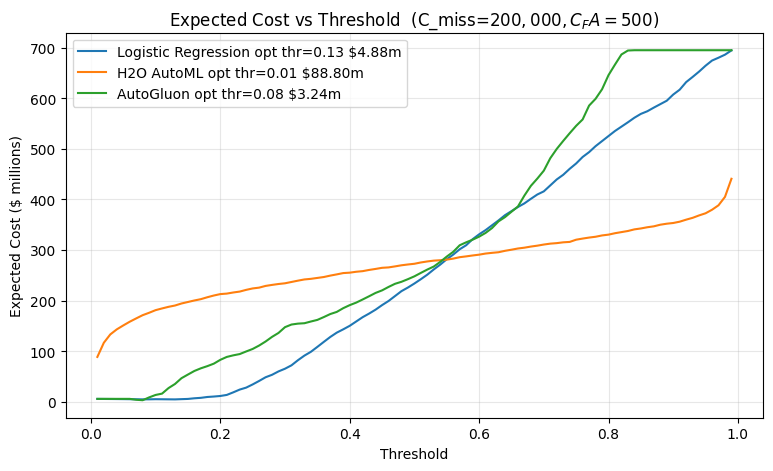

In [13]:
C_MISS, C_FA = 200_000, 500

plt.figure(figsize=(9, 5))
for name, prob in models.items():
    costs = np.array([expected_cost(y_true, prob, t, C_MISS, C_FA) for t in thresholds])
    best = costs.argmin()
    plt.plot(thresholds, costs / 1_000_000, label=f'{name} opt thr={thresholds[best]:.2f} ${costs[best]/1_000_000:.2f}m')
plt.xlabel('Threshold')
plt.ylabel('Expected Cost ($ millions)')
plt.title(f'Expected Cost vs Threshold  (C_miss=${C_MISS:,}, C_FA=${C_FA:,})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

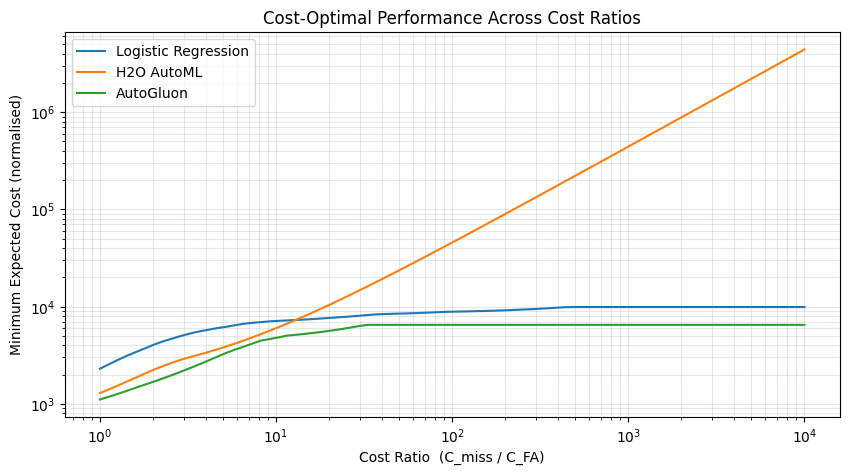

Winner distribution across ratio sweep:
AutoGluon    80
Name: count, dtype: int64


In [4]:
ratios = np.logspace(0, 4, 80)
min_costs = {name: [] for name in models}

for r in ratios:
    for name, prob in models.items():
        costs = np.array([expected_cost(y_true, prob, t, r, 1.0) for t in thresholds])
        min_costs[name].append(costs.min())

plt.figure(figsize=(10, 5))
for name, series in min_costs.items():
    plt.plot(ratios, series, label=name)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Cost Ratio  (C_miss / C_FA)')
plt.ylabel('Minimum Expected Cost (normalised)')
plt.title('Cost-Optimal Performance Across Cost Ratios')
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.show()

winner_by_ratio = pd.DataFrame(min_costs, index=ratios).idxmin(axis=1)
print('Winner distribution across ratio sweep:')
print(winner_by_ratio.value_counts())

In [11]:
scenarios = {
    'Onshore low-risk (electrical)': (50_000, 1_000),
    'Onshore gearbox replacement': (200_000, 500),
    'Offshore typical': (500_000, 2_000),
    'Offshore worst-case (vessel)': (1_000_000, 5_000)
}

rows = []
for scen, (cm, cfa) in scenarios.items():
    for name, prob in models.items():
        costs = np.array([expected_cost(y_true, prob, t, cm, cfa) for t in thresholds])
        best = costs.argmin()
        rows.append({
            'Scenario': scen,
            'Model': name,
            'Opt Threshold': round(thresholds[best], 2),
            'Min Cost ($)': int(costs[best]),
        })

df = pd.DataFrame(rows)
df['Winner'] = df.groupby('Scenario')['Min Cost ($)'].transform('min') == df['Min Cost ($)']
print(df.to_string(index=False))

                     Scenario               Model  Opt Threshold  Min Cost ($)  Winner
Onshore low-risk (electrical) Logistic Regression           0.15       8467000   False
Onshore low-risk (electrical)          H2O AutoML           0.01      23596000   False
Onshore low-risk (electrical)           AutoGluon           0.08       6488000    True
  Onshore gearbox replacement Logistic Regression           0.13       4881000   False
  Onshore gearbox replacement          H2O AutoML           0.01      88798000   False
  Onshore gearbox replacement           AutoGluon           0.08       3244000    True
             Offshore typical Logistic Regression           0.13      18624000   False
             Offshore typical          H2O AutoML           0.01     223192000   False
             Offshore typical           AutoGluon           0.08      12976000    True
 Offshore worst-case (vessel) Logistic Regression           0.13      45810000   False
 Offshore worst-case (vessel)          H2O 

In [7]:
ag_true = np.load(base + 'ag_y_true.npy')
h2o_true = np.load(base + 'h2o_y_true.npy')
lr_true = np.load(base + 'lr_y_true.npy')
print(len(ag_true), len(h2o_true), len(lr_true))
print('AG==H2O:', np.array_equal(ag_true, h2o_true))
print('AG==LR: ', np.array_equal(ag_true, lr_true))

15329 15329 15329
AG==H2O: True
AG==LR:  True


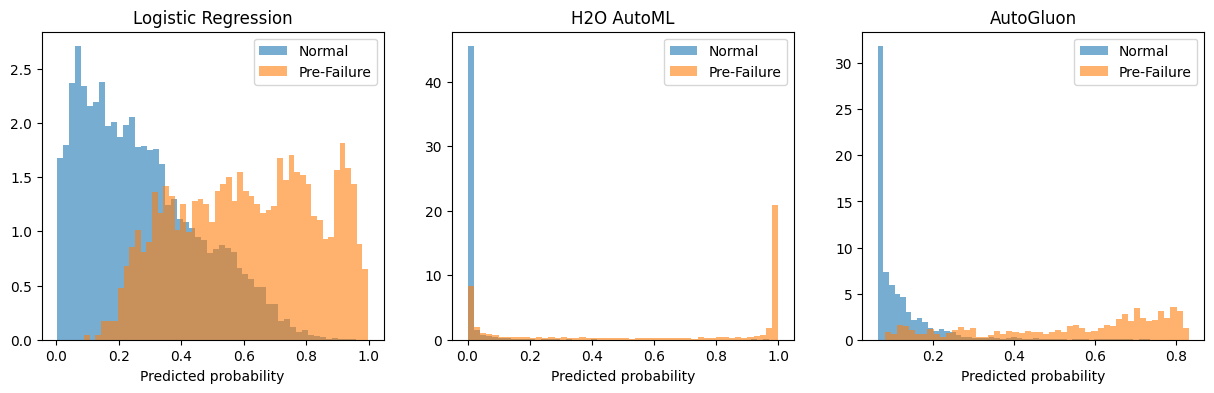

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, prob) in zip(axes, models.items()):
    ax.hist(prob[y_true == 0], bins=50, alpha=0.6, label='Normal',      density=True)
    ax.hist(prob[y_true == 1], bins=50, alpha=0.6, label='Pre-Failure', density=True)
    ax.set_title(name)
    ax.set_xlabel('Predicted probability')
    ax.legend()
plt.show()